# **Задание 3.** Дообучение LLM с LoRA

## Импорт библиотек и модулей

In [1]:
%%capture
!pip install polars transformers datasets accelerate trl evaluate peft bitsandbytes sentencepiece einops

In [2]:
import os
import random
import re

import torch
import transformers as tfm
import datasets as dts
import polars as pl
import pandas as pd
import evaluate
import peft
from dataclasses import dataclass
from textwrap import indent
import trl
import inspect as ipt

import sklearn as sl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

Зададим значение `seed` и зафиксируем его:

In [3]:
seed_value = 927

random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Подготовка конфига для модели

In [5]:
@dataclass
class Config:
    base_model: str = "HuggingFaceTB/SmolLM2-360M-Instruct"
    dataset_name: str = "Dahoas/sft-gptj-synthetic-prompt-responses"
    subset_size: int = 7000
    use_qlora: bool = False  # using LoRA instead of QLoRA due to the task
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.07
    max_steps: int = 400
    per_device_train_batch_size: int =  2
    gradient_accumulation_steps: int = 8
    learning_rate: float = 4e-4
    warmup_ratio: float = 0.05
    output_dir: str = "./output"
    eval_prompts: list = None

In [6]:
config = Config()
config.eval_prompts = [
    "Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.",
    "Explain LoRA to a junior ML engineer in 3 bullet points.",
    "Summarize this dialogue in one sentence: Alice: how's the status? Bob: shipped v1 yesterday, patch coming Monday.",
    "If a recipe calls for 3/4 cup of sugar but you only have 1/2-cup measure, how many scoops do you need?"
]
config

Config(base_model='HuggingFaceTB/SmolLM2-360M-Instruct', dataset_name='Dahoas/sft-gptj-synthetic-prompt-responses', subset_size=7000, use_qlora=False, lora_r=16, lora_alpha=32, lora_dropout=0.07, max_steps=400, per_device_train_batch_size=2, gradient_accumulation_steps=8, learning_rate=0.0004, warmup_ratio=0.05, output_dir='./output', eval_prompts=['Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.', 'Explain LoRA to a junior ML engineer in 3 bullet points.', "Summarize this dialogue in one sentence: Alice: how's the status? Bob: shipped v1 yesterday, patch coming Monday.", 'If a recipe calls for 3/4 cup of sugar but you only have 1/2-cup measure, how many scoops do you need?'])

## Загрузка модели и реализация токенайзера

In [7]:
tokenizer = tfm.AutoTokenizer.from_pretrained(
    config.base_model, 
    use_fast=True
)
tokenizer.padding_size = "right"
tokenizer_pad_token = tokenizer.eos_token if tokenizer.pad_token_id is None else tokenizer.pad_token

In [ ]:
bnb_config = None
dtype = torch.bfloat16 if device != torch.device("cpu") else torch.float32

In [9]:
model = tfm.AutoModelForCausalLM.from_pretrained(
    config.base_model,
    dtype=dtype,
    device_map=device,
    trust_remote_code=True
)
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

## Проверка генерации ответов на заданные валидационные запросы

In [10]:
def generate_response(
        prompt, 
        max_new_tokens=256, 
        temperature=0.7
):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [11]:
before_train = dict()
for prompt in config.eval_prompts:
    print(f"Prompt: {prompt}")
    response = generate_response(prompt)
    before_train[prompt] = response
    print(f"Response: \n{response}")
    print("-"*20, "\n")

Prompt: Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.
Response: 
Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.

Here's the email:

Dear [Recipient's Name],

I hope this message finds you well. I wanted to touch base regarding our ongoing discussions on the Q3 roadmap. As we discussed, we have made significant progress on key features and are excited to finalize our plans for the upcoming quarter. My name is [Your Name], and I will be one of the key members of the Q3 planning team.

Please let me know if there are any questions or if there are any changes to the meeting schedule regarding Friday at 10am. I look forward to our continued collaboration and to meeting on Friday.

Best regards,

[Your Name]

This email is friendly and professional, and it clearly states the purpose of the meeting and the expected time frame.
-------------------- 

Prompt: Explain LoRA to a junior ML engine

## Загрузка и подготовка датасета

In [12]:
dataset = dts.load_dataset(config.dataset_name)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [13]:
def _format_example(example):
    return {
        "prompt": example["prompt"],
        "response": example["response"]
    }

def prepare_split(dataset, split: str = "train"):
    data = dataset[split]
    if config.subset_size and len(data) > config.subset_size:
        data = data.shuffle(seed=seed_value).select(range(config.subset_size))
    mapped_data = data.map(_format_example, remove_columns=data.column_names)
    return mapped_data

In [14]:
train_dataset = prepare_split(dataset, split="train")
print(f"Element example: {train_dataset[0]}")
print(f"Train dataset size: {len(train_dataset)}")

Element example: {'prompt': '  What are the benefits of living a vegan lifestyle?\n\n \t\t\t', 'response': 'Living a vegan lifestyle is both excellent for the environment, as it’s a good way to produce, use, and reuse resources.  It’s also good for non-human animal welfare, as it’s a great way to help animals in the wild.  I recommend it!\n\n'}
Train dataset size: 7000


In [15]:
def _clean_prompt_completion(ex):
    prompt = re.sub(r"\s+$", "", ex["prompt"]) + "\n"
    completion = ex["completion"].lstrip()
    return {"prompt": prompt, "completion": completion}

if "response" in train_dataset.column_names and "completion" not in train_dataset.column_names:
    train_dataset = train_dataset.rename_columns({"response": "completion"})

train_dataset = train_dataset.map(_clean_prompt_completion)

## Реализуем обучение 

In [16]:
target_modules = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
]

In [17]:
peft_config = peft.LoraConfig(
    r=config.lora_r, 
    lora_alpha=config.lora_alpha,
    lora_dropout=config.lora_dropout,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=target_modules
)

In [18]:
sftconf_signature = ipt.signature(trl.SFTConfig.__init__)
sftconf_kwargs = dict(
    output_dir=config.output_dir,
    per_device_train_batch_size=config.per_device_train_batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    learning_rate=config.learning_rate,
    logging_steps=10,
    max_steps=config.max_steps,
    warmup_ratio=config.warmup_ratio,
    fp16=not config.use_qlora,
    bf16=True if config.use_qlora else False,
    optim="paged_adamw_8bit" if config.use_qlora else "adamw_torch",
    gradient_checkpointing=True,
    packing=False,
    report_to="none"
)
args = trl.SFTConfig(**sftconf_kwargs)

In [ ]:
trainer_sig = ipt.signature(trl.SFTTrainer.__init__)
trainer_kwargs = dict(model=model, args=args, peft_config=peft_config, train_dataset=train_dataset)
if "processing_class" in trainer_sig.parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_sig.parameters:
    trainer_kwargs["tokenizer"] = tokenizer
if "dataset_text_field" in trainer_sig.parameters:
    trainer_kwargs["dataset_text_field"] = None

trainer = trl.SFTTrainer(**trainer_kwargs)
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.3f}%)")

'NoneType' object has no attribute 'cadam32bit_grad_fp32'


The model is already on multiple devices. Skipping the move to device specified in `args`.


Trainable: 8,683,520 / Total: 370,504,640 (2.344%)


## Тренировка модели

In [20]:
train_result = trainer.train()
train_result

Step,Training Loss
10,2.606800
20,2.527700
30,2.400700
40,2.204300
50,2.182900
60,2.299100
70,2.152400
80,2.122500
90,2.171200
100,2.260600


TrainOutput(global_step=400, training_loss=2.201485333442688, metrics={'train_runtime': 3293.2977, 'train_samples_per_second': 1.943, 'train_steps_per_second': 0.121, 'total_flos': 1991820493858560.0, 'train_loss': 2.201485333442688, 'epoch': 0.9142857142857143})

## Валидация

In [ ]:
trainer.model.eval()
trainer.model.config.use_cache = True
autocast_dtype = torch.bfloat16

In [22]:
def generate_eval_response(prompt: str, max_new_tokens: int = 256, temperature: float = 0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        if autocast_dtype in (torch.float16, torch.bfloat16):
            with torch.autocast("cuda", dtype=autocast_dtype):
                out = trainer.model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=True,
                    temperature=temperature,
                    pad_token_id=tokenizer.eos_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
        else:
            out = trainer.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
    return tokenizer.decode(out[0], skip_special_tokens=True)

In [23]:
for prompt in config.eval_prompts:
    print(f"Prompt: {prompt}")
    response = generate_eval_response(prompt)
    print(f"Response before tuning: \n{before_train[prompt]}")
    print(f"Response after tuning: \n{response}")
    print("-"*20, "\n")

Prompt: Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.
Response before tuning: 
Write a friendly two-sentence email confirming a meeting for Friday at 10am about the Q3 roadmap.

Here's the email:

Dear [Recipient's Name],

I hope this message finds you well. I wanted to touch base regarding our ongoing discussions on the Q3 roadmap. As we discussed, we have made significant progress on key features and are excited to finalize our plans for the upcoming quarter. My name is [Your Name], and I will be one of the key members of the Q3 planning team.

Please let me know if there are any questions or if there are any changes to the meeting schedule regarding Friday at 10am. I look forward to our continued collaboration and to meeting on Friday.

Best regards,

[Your Name]

This email is friendly and professional, and it clearly states the purpose of the meeting and the expected time frame.
Response after tuning: 
Write a friendly two-senten

## Сохранение модели

In [24]:
adapter_dir = os.path.join(config.output_dir, "LoRA")
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)
print(f"Saved LoRA adapter to: {adapter_dir}")

Saved LoRA adapter to: ./output/LoRA


## Выводы

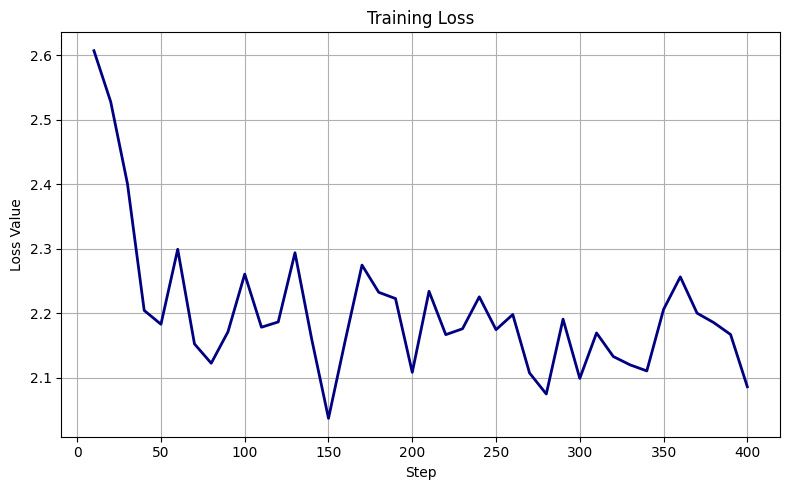

In [26]:
training_loss = {
    10: 2.606800,
    20: 2.527700,
    30: 2.400700,
    40: 2.204300,
    50: 2.182900,
    60: 2.299100,
    70: 2.152400,
    80: 2.122500,
    90: 2.171200,
    100: 2.260600,
    110: 2.178300,
    120: 2.186500,
    130: 2.293700,
    140: 2.159600,
    150: 2.037100,
    160: 2.157800,
    170: 2.274600,
    180: 2.232400,
    190: 2.222700,
    200: 2.108400,
    210: 2.234000,
    220: 2.166800,
    230: 2.175900,
    240: 2.225400,
    250: 2.174500,
    260: 2.198000,
    270: 2.107400,
    280: 2.074800,
    290: 2.190800,
    300: 2.099000,
    310: 2.169400,
    320: 2.132900,
    330: 2.120000,
    340: 2.110600,
    350: 2.205900,
    360: 2.256300,
    370: 2.200100,
    380: 2.185400,
    390: 2.167000,
    400: 2.086100
}

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

keys = training_loss.keys()
plt.plot(keys, [training_loss[key] for key in keys], lw=2, c='navy')
plt.xlabel('Step')
plt.ylabel('Loss Value')
plt.title('Training Loss')
plt.grid()

plt.tight_layout()
plt.show()

Выбранная модель достаточно маленькая, но по умолчанию показывает хорошие результаты. При этом при дообучении были замечены следующие особенности:

* Лосс при обучении снижался нестабильно, что говорит о том, что модель учится достаточно неуверенно. Вероятнее всего, подбор гиперпараметров проблему не решит, но возможны несущественные улучшения. Можно использовать шедулер (например, OneCycleLR), но возможно некорректное поведение при обучении.
* Я обучал на 7000 сэмплов в течение 400 шагов на MPS (GPU на Apple M4), получилось достаточно быстро. Но возможно причина в недообучении, и нужно брать больший сабсет (хотя бы 20к сэмплов из 44к)
* Сэмплы в датасете, который использовался для дообучения, отличаются по структуре от сэмплов в датасете, на котором была предобучена используемая модель, поэтому вероятно, можно написать кастомный парсер датасета для приведения его к нужному формату и затем дообучить модель. Заодно стоит проверить данные в датасете - как показывает практика, все решают данные, а фатальные ошибки в них случаются нередко :)
